# Seoul Air Pollution Analysis and PM2.5 Forecasting

## Objective

The objective of this project is to analyze air quality trends across Seoul monitoring stations and develop a machine learning model capable of forecasting PM2.5 concentrations using pollutant measurements and temporal features.

## Dataset Description

The project uses three datasets:

1. Measurement Information
   - Pollutant measurements
   - Timestamps
   - Station identifiers

2. Item Information
   - Pollutant metadata
   - Units of measurement

3. Station Information
   - District names
   - Geographic coordinates

In [5]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt


In [6]:
measurement = pd.read_csv("Measurement_info.csv")
item = pd.read_csv("Measurement_item_info.csv")
station = pd.read_csv("Measurement_station_info.csv")

In [7]:
measurement.head()


,Measurement date,Station code,Item code,Average value,Instrument status
0,2017-01-01 00:00,101,1,0.004,0
1,2017-01-01 00:00,101,3,0.059,0
2,2017-01-01 00:00,101,5,1.200,0
3,2017-01-01 00:00,101,6,0.002,0
4,2017-01-01 00:00,101,8,73.000,0


In [8]:
item.head()


,Item code,Item name,Unit of measurement,Good(Blue),Normal(Green),Bad(Yellow),Very bad(Red)
0,1,SO2,ppm,0.02,0.05,0.15,1.0
1,3,NO2,ppm,0.03,0.06,0.20,2.0
2,5,CO,ppm,2.00,9.00,15.00,50.0
3,6,O3,ppm,0.03,0.09,0.15,0.5
4,8,PM10,Mircrogram/m3,30.00,80.00,150.00,600.0


In [9]:
station.head()

,Station code,Station name(district),Address,Latitude,Longitude
0,101,Jongno-gu,"19, Jong-ro 35ga-gil, Jongno-gu, Seoul, Republ...",37.572016,127.005008
1,102,Jung-gu,"15, Deoksugung-gil, Jung-gu, Seoul, Republic o...",37.564263,126.974676
2,103,Yongsan-gu,"136, Hannam-daero, Yongsan-gu, Seoul, Republic...",37.540033,127.004850
3,104,Eunpyeong-gu,"215, Jinheung-ro, Eunpyeong-gu, Seoul, Republi...",37.609823,126.934848
4,105,Seodaemun-gu,"32, Segeomjeong-ro 4-gil, Seodaemun-gu, Seoul,...",37.593742,126.949679


In [10]:
measurement_df = measurement.merge(item, on='Item code', how = 'left')
measurement_df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 3885066 entries, 0 to 3885065
Data columns (total 11 columns):
 #   Column               Dtype  
---  ------               -----  
 0   Measurement date     object 
 1   Station code         int64  
 2   Item code            int64  
 3   Average value        float64
 4   Instrument status    int64  
 5   Item name            object 
 6   Unit of measurement  object 
 7   Good(Blue)           float64
 8   Normal(Green)        float64
 9   Bad(Yellow)          float64
 10  Very bad(Red)        float64
dtypes: float64(5), int64(3), object(3)
memory usage: 355.7+ MB


In [11]:
measurement.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3885066 entries, 0 to 3885065
Data columns (total 5 columns):
 #   Column             Dtype  
---  ------             -----  
 0   Measurement date   object 
 1   Station code       int64  
 2   Item code          int64  
 3   Average value      float64
 4   Instrument status  int64  
dtypes: float64(1), int64(3), object(1)
memory usage: 148.2+ MB


In [12]:
item.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6 entries, 0 to 5
Data columns (total 7 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Item code            6 non-null      int64  
 1   Item name            6 non-null      object 
 2   Unit of measurement  6 non-null      object 
 3   Good(Blue)           6 non-null      float64
 4   Normal(Green)        6 non-null      float64
 5   Bad(Yellow)          6 non-null      float64
 6   Very bad(Red)        6 non-null      float64
dtypes: float64(4), int64(1), object(2)
memory usage: 464.0+ bytes


In [13]:
print(measurement.columns.tolist())
print(item.columns.tolist())
print(station.columns.tolist())

['Measurement date', 'Station code', 'Item code', 'Average value', 'Instrument status']
['Item code', 'Item name', 'Unit of measurement', 'Good(Blue)', 'Normal(Green)', 'Bad(Yellow)', 'Very bad(Red)']
['Station code', 'Station name(district)', 'Address', 'Latitude', 'Longitude']


In [14]:
measurement_df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 3885066 entries, 0 to 3885065
Data columns (total 11 columns):
 #   Column               Dtype  
---  ------               -----  
 0   Measurement date     object 
 1   Station code         int64  
 2   Item code            int64  
 3   Average value        float64
 4   Instrument status    int64  
 5   Item name            object 
 6   Unit of measurement  object 
 7   Good(Blue)           float64
 8   Normal(Green)        float64
 9   Bad(Yellow)          float64
 10  Very bad(Red)        float64
dtypes: float64(5), int64(3), object(3)
memory usage: 355.7+ MB


In [15]:
station.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25 entries, 0 to 24
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Station code            25 non-null     int64  
 1   Station name(district)  25 non-null     object 
 2   Address                 25 non-null     object 
 3   Latitude                25 non-null     float64
 4   Longitude               25 non-null     float64
dtypes: float64(2), int64(1), object(2)
memory usage: 1.1+ KB


In [16]:
station_df = measurement_df.merge(
    station,
    on='Station code',
    how='left'
)
station_df.head()

,Measurement date,Station code,Item code,Average value,Instrument status,Item name,Unit of measurement,Good(Blue),Normal(Green),Bad(Yellow),Very bad(Red),Station name(district),Address,Latitude,Longitude
0,2017-01-01 00:00,101,1,0.004,0,SO2,ppm,0.02,0.05,0.15,1.0,Jongno-gu,"19, Jong-ro 35ga-gil, Jongno-gu, Seoul, Republ...",37.572016,127.005008
1,2017-01-01 00:00,101,3,0.059,0,NO2,ppm,0.03,0.06,0.20,2.0,Jongno-gu,"19, Jong-ro 35ga-gil, Jongno-gu, Seoul, Republ...",37.572016,127.005008
2,2017-01-01 00:00,101,5,1.200,0,CO,ppm,2.00,9.00,15.00,50.0,Jongno-gu,"19, Jong-ro 35ga-gil, Jongno-gu, Seoul, Republ...",37.572016,127.005008
3,2017-01-01 00:00,101,6,0.002,0,O3,ppm,0.03,0.09,0.15,0.5,Jongno-gu,"19, Jong-ro 35ga-gil, Jongno-gu, Seoul, Republ...",37.572016,127.005008
4,2017-01-01 00:00,101,8,73.000,0,PM10,Mircrogram/m3,30.00,80.00,150.00,600.0,Jongno-gu,"19, Jong-ro 35ga-gil, Jongno-gu, Seoul, Republ...",37.572016,127.005008


In [17]:
df = station_df
df.head()

,Measurement date,Station code,Item code,Average value,Instrument status,Item name,Unit of measurement,Good(Blue),Normal(Green),Bad(Yellow),Very bad(Red),Station name(district),Address,Latitude,Longitude
0,2017-01-01 00:00,101,1,0.004,0,SO2,ppm,0.02,0.05,0.15,1.0,Jongno-gu,"19, Jong-ro 35ga-gil, Jongno-gu, Seoul, Republ...",37.572016,127.005008
1,2017-01-01 00:00,101,3,0.059,0,NO2,ppm,0.03,0.06,0.20,2.0,Jongno-gu,"19, Jong-ro 35ga-gil, Jongno-gu, Seoul, Republ...",37.572016,127.005008
2,2017-01-01 00:00,101,5,1.200,0,CO,ppm,2.00,9.00,15.00,50.0,Jongno-gu,"19, Jong-ro 35ga-gil, Jongno-gu, Seoul, Republ...",37.572016,127.005008
3,2017-01-01 00:00,101,6,0.002,0,O3,ppm,0.03,0.09,0.15,0.5,Jongno-gu,"19, Jong-ro 35ga-gil, Jongno-gu, Seoul, Republ...",37.572016,127.005008
4,2017-01-01 00:00,101,8,73.000,0,PM10,Mircrogram/m3,30.00,80.00,150.00,600.0,Jongno-gu,"19, Jong-ro 35ga-gil, Jongno-gu, Seoul, Republ...",37.572016,127.005008


In [18]:
df.isnull().sum()

Measurement date          0
Station code              0
Item code                 0
Average value             0
Instrument status         0
Item name                 0
Unit of measurement       0
Good(Blue)                0
Normal(Green)             0
Bad(Yellow)               0
Very bad(Red)             0
Station name(district)    0
Address                   0
Latitude                  0
Longitude                 0
dtype: int64

In [19]:
df['Instrument status'].value_counts()

0    3775778
8      32341
1      29717
4      22752
9      20490
2       3988
Name: Instrument status, dtype: int64

### Instrument Status Analysis

The Instrument Status column was investigated and found to represent sensor status codes rather than pollution measurements. Only rows with status code 0 (valid measurements) were retained.

In [20]:
df_clean = df[df['Instrument status'] == 0]
df_clean.head()

,Measurement date,Station code,Item code,Average value,Instrument status,Item name,Unit of measurement,Good(Blue),Normal(Green),Bad(Yellow),Very bad(Red),Station name(district),Address,Latitude,Longitude
0,2017-01-01 00:00,101,1,0.004,0,SO2,ppm,0.02,0.05,0.15,1.0,Jongno-gu,"19, Jong-ro 35ga-gil, Jongno-gu, Seoul, Republ...",37.572016,127.005008
1,2017-01-01 00:00,101,3,0.059,0,NO2,ppm,0.03,0.06,0.20,2.0,Jongno-gu,"19, Jong-ro 35ga-gil, Jongno-gu, Seoul, Republ...",37.572016,127.005008
2,2017-01-01 00:00,101,5,1.200,0,CO,ppm,2.00,9.00,15.00,50.0,Jongno-gu,"19, Jong-ro 35ga-gil, Jongno-gu, Seoul, Republ...",37.572016,127.005008
3,2017-01-01 00:00,101,6,0.002,0,O3,ppm,0.03,0.09,0.15,0.5,Jongno-gu,"19, Jong-ro 35ga-gil, Jongno-gu, Seoul, Republ...",37.572016,127.005008
4,2017-01-01 00:00,101,8,73.000,0,PM10,Mircrogram/m3,30.00,80.00,150.00,600.0,Jongno-gu,"19, Jong-ro 35ga-gil, Jongno-gu, Seoul, Republ...",37.572016,127.005008


In [21]:
pivot_df = df_clean.pivot_table(
    index=[
        'Measurement date',
        'Station code',
        'Station name(district)',
        'Latitude',
        'Longitude'
    ],
    columns='Item name',
    values='Average value'
).reset_index()
pivot_df.head()

Item name,Measurement date,Station code,Station name(district),Latitude,Longitude,CO,NO2,O3,PM10,PM2.5,SO2
0,2017-01-01 00:00,101,Jongno-gu,37.572016,127.005008,1.2,0.059,0.002,73.0,57.0,0.004
1,2017-01-01 00:00,102,Jung-gu,37.564263,126.974676,1.3,0.068,0.002,77.0,63.0,0.006
2,2017-01-01 00:00,103,Yongsan-gu,37.540033,127.004850,1.4,0.039,0.002,70.0,68.0,0.005
3,2017-01-01 00:00,104,Eunpyeong-gu,37.609823,126.934848,0.6,0.045,0.003,73.0,46.0,0.005
4,2017-01-01 00:00,105,Seodaemun-gu,37.593742,126.949679,1.0,0.044,0.004,81.0,44.0,0.005


pivot_df = df.pivot_table(
    index=[
        'Measurement date',
        'Station code',
        'Station name(district)',
        'Latitude',
        'Longitude'
    ],
    columns='Item name',
    values='Average value'
).reset_index()
pivot_df.head()

## Table 
| Column | Full Name                  | What It Measures                            |
| ------ | -------------------------- | ------------------------------------------- |
| SO2    | Sulfur Dioxide             | Pollution mainly from burning fossil fuels  |
| NO2    | Nitrogen Dioxide           | Pollution from vehicle exhaust and industry |
| CO     | Carbon Monoxide            | Incomplete fuel combustion                  |
| O3     | Ozone                      | Secondary pollutant formed in sunlight      |
| PM10   | Particulate Matter ≤10 µm  | Dust and larger airborne particles          |
| PM2.5  | Particulate Matter ≤2.5 µm | Very fine particles that can enter lungs    |


In [22]:
pivot_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 637199 entries, 0 to 637198
Data columns (total 11 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   Measurement date        637199 non-null  object 
 1   Station code            637199 non-null  int64  
 2   Station name(district)  637199 non-null  object 
 3   Latitude                637199 non-null  float64
 4   Longitude               637199 non-null  float64
 5   CO                      629784 non-null  float64
 6   NO2                     632564 non-null  float64
 7   O3                      631120 non-null  float64
 8   PM10                    624408 non-null  float64
 9   PM2.5                   627158 non-null  float64
 10  SO2                     630744 non-null  float64
dtypes: float64(8), int64(1), object(2)
memory usage: 53.5+ MB


In [23]:
pivot_df.describe()

Item name,Station code,Latitude,Longitude,CO,NO2,O3,PM10,PM2.5,SO2
count,637199.000000,637199.000000,637199.000000,629784.000000,632564.000000,631120.000000,624408.000000,627158.000000,630744.000000
mean,113.020039,37.553457,126.989422,0.516451,0.028642,0.024363,41.798675,24.081037,0.004321
std,7.213189,0.053384,0.078797,0.239620,0.015967,0.019112,29.299224,18.847195,0.001669
min,101.000000,37.452357,126.835151,0.000000,0.000000,0.000000,1.000000,1.000000,0.001000
25%,107.000000,37.517528,126.927102,0.400000,0.016000,0.009000,23.000000,12.000000,0.003000
50%,113.000000,37.544962,127.004850,0.500000,0.025000,0.021000,35.000000,19.000000,0.004000
75%,119.000000,37.584848,127.047470,0.600000,0.038000,0.035000,53.000000,31.000000,0.005000
max,125.000000,37.658774,127.136792,3.200000,0.123000,0.215000,470.000000,205.000000,0.041000


In [24]:
pivot_df.isnull().sum()

Item name
Measurement date              0
Station code                  0
Station name(district)        0
Latitude                      0
Longitude                     0
CO                         7415
NO2                        4635
O3                         6079
PM10                      12791
PM2.5                     10041
SO2                        6455
dtype: int64

In [25]:
pivot_df.isnull().sum().sort_values(ascending=False)

Item name
PM10                      12791
PM2.5                     10041
CO                         7415
SO2                        6455
O3                         6079
NO2                        4635
Measurement date              0
Station code                  0
Station name(district)        0
Latitude                      0
Longitude                     0
dtype: int64

In [26]:
pivot_df.shape

(637199, 11)

In [27]:
missing_percent = (  pivot_df.isnull().sum() / len(pivot_df)) * 100

print(missing_percent.sort_values(ascending=False))

Item name
PM10                      2.007379
PM2.5                     1.575803
CO                        1.163687
SO2                       1.013027
O3                        0.954019
NO2                       0.727402
Measurement date          0.000000
Station code              0.000000
Station name(district)    0.000000
Latitude                  0.000000
Longitude                 0.000000
dtype: float64


## missing % is below 5% so its considered small amount of missing data


In [28]:
pivot_df = pivot_df.dropna()
pivot_df.isnull().sum()

Item name
Measurement date          0
Station code              0
Station name(district)    0
Latitude                  0
Longitude                 0
CO                        0
NO2                       0
O3                        0
PM10                      0
PM2.5                     0
SO2                       0
dtype: int64

In [29]:
pivot_df['Measurement date'] = pd.to_datetime(
    pivot_df['Measurement date']
)

pivot_df['Year'] = pivot_df['Measurement date'].dt.year
pivot_df['Month'] = pivot_df['Measurement date'].dt.month
pivot_df['Day'] = pivot_df['Measurement date'].dt.day
pivot_df['Hour'] = pivot_df['Measurement date'].dt.hour

In [30]:
pivot_df

Item name,Measurement date,Station code,Station name(district),Latitude,Longitude,CO,NO2,O3,PM10,PM2.5,SO2,Year,Month,Day,Hour
0,2017-01-01 00:00:00,101,Jongno-gu,37.572016,127.005008,1.2,0.059,0.002,73.0,57.0,0.004,2017,1,1,0
1,2017-01-01 00:00:00,102,Jung-gu,37.564263,126.974676,1.3,0.068,0.002,77.0,63.0,0.006,2017,1,1,0
2,2017-01-01 00:00:00,103,Yongsan-gu,37.540033,127.004850,1.4,0.039,0.002,70.0,68.0,0.005,2017,1,1,0
3,2017-01-01 00:00:00,104,Eunpyeong-gu,37.609823,126.934848,0.6,0.045,0.003,73.0,46.0,0.005,2017,1,1,0
4,2017-01-01 00:00:00,105,Seodaemun-gu,37.593742,126.949679,1.0,0.044,0.004,81.0,44.0,0.005,2017,1,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
637194,2019-12-31 23:00:00,121,Gwanak-gu,37.487355,126.927102,0.5,0.042,0.013,29.0,16.0,0.003,2019,12,31,23
637195,2019-12-31 23:00:00,122,Seocho-gu,37.504547,126.994458,0.4,0.047,0.007,24.0,15.0,0.003,2019,12,31,23
637196,2019-12-31 23:00:00,123,Gangnam-gu,37.517528,127.047470,0.5,0.039,0.003,19.0,13.0,0.003,2019,12,31,23
637197,2019-12-31 23:00:00,124,Songpa-gu,37.502686,127.092509,0.5,0.035,0.004,20.0,13.0,0.003,2019,12,31,23


### Correlation Analysis

This analysis examines relationships among pollutants and identifies which pollutants are most strongly associated with PM2.5 concentrations.

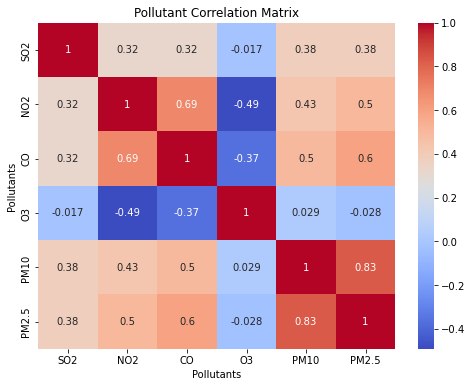

In [31]:
corr = pivot_df[
    ['SO2','NO2','CO','O3','PM10','PM2.5']
].corr()

plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title('Pollutant Correlation Matrix')
plt.xlabel("Pollutants")
plt.ylabel("Pollutants")
plt.show()

Correlation Values

The values range from:

where:

Correlation (r)	|Meaning
+1 |	Perfect positive relationship
+0.8 |	Strong positive relationship
+0.5 | Moderate positive relationship
0 |	No relationship
-0.5 |	Moderate negative relationship
-1 | Perfect negative relationship

## Findings from heatmap(correration with PM2.5)

1. PM10 = 0.83
2. CO = 0.6

In [32]:
top_districts = (pivot_df.groupby('Station name(district)')
                 ['PM2.5'].mean().sort_values(ascending=False))

print(top_districts.head(10))  # top 10 most polluted districts

Station name(district)
Gwanak-gu          26.996015
Mapo-gu            26.860596
Yeongdeungpo-gu    26.805267
Yangcheon-gu       25.718525
Dongjak-gu         24.576028
Seongdong-gu       24.566988
Eunpyeong-gu       24.506509
Gangdong-gu        24.464389
Geumcheon-gu       24.401494
Nowon-gu           24.303619
Name: PM2.5, dtype: float64


### From the output above it looks like these are the most polluted districts with Avg PM2.5 more than other districts :

Gwanak-gu          26.996015;
Mapo-gu            26.860596;
Yeongdeungpo-gu    26.805267

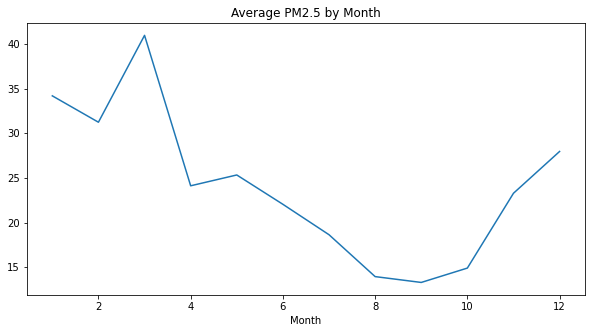

In [33]:
monthly_pm25 =( 
    pivot_df.groupby('Month')
    ['PM2.5']
    .mean())


monthly_pm25.plot(figsize=(10,5))
plt.title('Average PM2.5 by Month')
plt.show()

In [34]:
pivot_df['Measurement date'] = pd.to_datetime(
    pivot_df['Measurement date']
)

pivot_df['DayOfWeek'] = pivot_df['Measurement date'].dt.dayofweek

In [35]:
pivot_df.head()

Item name,Measurement date,Station code,Station name(district),Latitude,Longitude,CO,NO2,O3,PM10,PM2.5,SO2,Year,Month,Day,Hour,DayOfWeek
0,2017-01-01,101,Jongno-gu,37.572016,127.005008,1.2,0.059,0.002,73.0,57.0,0.004,2017,1,1,0,6
1,2017-01-01,102,Jung-gu,37.564263,126.974676,1.3,0.068,0.002,77.0,63.0,0.006,2017,1,1,0,6
2,2017-01-01,103,Yongsan-gu,37.540033,127.004850,1.4,0.039,0.002,70.0,68.0,0.005,2017,1,1,0,6
3,2017-01-01,104,Eunpyeong-gu,37.609823,126.934848,0.6,0.045,0.003,73.0,46.0,0.005,2017,1,1,0,6
4,2017-01-01,105,Seodaemun-gu,37.593742,126.949679,1.0,0.044,0.004,81.0,44.0,0.005,2017,1,1,0,6


In [36]:
pivot_df = pivot_df.sort_values('Measurement date')
pivot_df

Item name,Measurement date,Station code,Station name(district),Latitude,Longitude,CO,NO2,O3,PM10,PM2.5,SO2,Year,Month,Day,Hour,DayOfWeek
0,2017-01-01 00:00:00,101,Jongno-gu,37.572016,127.005008,1.2,0.059,0.002,73.0,57.0,0.004,2017,1,1,0,6
24,2017-01-01 00:00:00,125,Gangdong-gu,37.544962,127.136792,0.9,0.042,0.002,68.0,53.0,0.004,2017,1,1,0,6
23,2017-01-01 00:00:00,124,Songpa-gu,37.502686,127.092509,1.4,0.040,0.003,60.0,51.0,0.006,2017,1,1,0,6
22,2017-01-01 00:00:00,123,Gangnam-gu,37.517528,127.047470,0.8,0.040,0.002,63.0,48.0,0.005,2017,1,1,0,6
21,2017-01-01 00:00:00,122,Seocho-gu,37.504547,126.994458,1.3,0.039,0.005,82.0,39.0,0.005,2017,1,1,0,6
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
637175,2019-12-31 23:00:00,102,Jung-gu,37.564263,126.974676,0.5,0.036,0.002,22.0,18.0,0.003,2019,12,31,23,1
637174,2019-12-31 23:00:00,101,Jongno-gu,37.572016,127.005008,0.5,0.035,0.005,20.0,15.0,0.004,2019,12,31,23,1
637197,2019-12-31 23:00:00,124,Songpa-gu,37.502686,127.092509,0.5,0.035,0.004,20.0,13.0,0.003,2019,12,31,23,1
637185,2019-12-31 23:00:00,112,Gangbuk-gu,37.647930,127.011952,0.5,0.034,0.010,21.0,13.0,0.002,2019,12,31,23,1


pivot_df['Measurement date'].isnull().sum()

In [37]:
pivot_df = pivot_df.sort_values(
    ['Station code', 'Measurement date']
)

pivot_df['PM25_lag1'] = (                       # one hour
    pivot_df.groupby('Station code')['PM2.5']
    .shift(1)
)

pivot_df['PM25_lag24'] = (                      # one day
    pivot_df.groupby('Station code')['PM2.5']
    .shift(24)
)

In [38]:
pivot_df

Item name,Measurement date,Station code,Station name(district),Latitude,Longitude,CO,NO2,O3,PM10,PM2.5,SO2,Year,Month,Day,Hour,DayOfWeek,PM25_lag1,PM25_lag24
0,2017-01-01 00:00:00,101,Jongno-gu,37.572016,127.005008,1.2,0.059,0.002,73.0,57.0,0.004,2017,1,1,0,6,NaN,NaN
25,2017-01-01 01:00:00,101,Jongno-gu,37.572016,127.005008,1.2,0.058,0.002,71.0,59.0,0.004,2017,1,1,1,6,57.0,NaN
50,2017-01-01 02:00:00,101,Jongno-gu,37.572016,127.005008,1.2,0.056,0.002,70.0,59.0,0.004,2017,1,1,2,6,59.0,NaN
75,2017-01-01 03:00:00,101,Jongno-gu,37.572016,127.005008,1.2,0.056,0.002,70.0,58.0,0.004,2017,1,1,3,6,59.0,NaN
100,2017-01-01 04:00:00,101,Jongno-gu,37.572016,127.005008,1.2,0.051,0.002,69.0,61.0,0.003,2017,1,1,4,6,58.0,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
637098,2019-12-31 19:00:00,125,Gangdong-gu,37.544962,127.136792,0.5,0.028,0.013,23.0,17.0,0.003,2019,12,31,19,1,18.0,34.0
637123,2019-12-31 20:00:00,125,Gangdong-gu,37.544962,127.136792,0.4,0.025,0.015,25.0,19.0,0.003,2019,12,31,20,1,17.0,29.0
637148,2019-12-31 21:00:00,125,Gangdong-gu,37.544962,127.136792,0.4,0.023,0.015,24.0,17.0,0.003,2019,12,31,21,1,19.0,25.0
637173,2019-12-31 22:00:00,125,Gangdong-gu,37.544962,127.136792,0.5,0.040,0.004,25.0,18.0,0.003,2019,12,31,22,1,17.0,17.0


In [39]:
pivot_df = pivot_df.dropna()

In [40]:
pivot_df.shape

(604451, 18)

In [41]:
features = [
    'SO2',
    'NO2',
    'CO',
    'O3',
    'PM10',
    'Year',
    'Month',
    'Day',
    'Hour',
    'DayOfWeek',
    'PM25_lag1',
    'PM25_lag24'
]

target = 'PM2.5'

In [42]:
X = pivot_df[features]
y = pivot_df[target]

In [43]:
split_index = int(len(pivot_df) * 0.8)

X_train = X.iloc[:split_index]
X_test = X.iloc[split_index:]

y_train = y.iloc[:split_index]
y_test = y.iloc[split_index:]

### Random Forest Forecasting Model

A Random Forest Regressor was trained to predict PM2.5 concentrations using pollutant measurements, temporal features, and lag-based features.

In [44]:
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

model.fit(X_train, y_train)

RandomForestRegressor(n_jobs=-1, random_state=42)

In [45]:
predictions = model.predict(X_test)

In [46]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

mae = mean_absolute_error(y_test, predictions)

rmse = mean_squared_error(
    y_test,
    predictions,
    squared=False
)

r2 = r2_score(y_test, predictions)

print("MAE:", mae)
print("RMSE:", rmse)
print("R2:", r2)

MAE: 3.2079206571760235
RMSE: 4.565590351997941
R2: 0.9434874666548447


C:\Users\ishan\anaconda3\lib\site-packages\sklearn\metrics\_regression.py:483: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


In [47]:
importance = pd.DataFrame({
    'Feature': features,
    'Importance': model.feature_importances_
})

importance = importance.sort_values(
    by='Importance',
    ascending=False
)

print(importance)

       Feature  Importance
10   PM25_lag1    0.916722
4         PM10    0.035445
11  PM25_lag24    0.007174
1          NO2    0.006742
3           O3    0.006579
7          Day    0.005440
8         Hour    0.005333
2           CO    0.004246
6        Month    0.004022
0          SO2    0.003500
9    DayOfWeek    0.003076
5         Year    0.001720


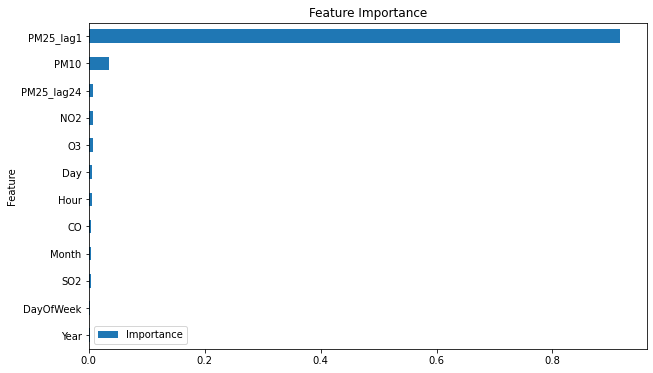

In [48]:
importance.sort_values(
    by='Importance'
).plot(
    x='Feature',
    y='Importance',
    kind='barh',
    figsize=(10,6)
)

plt.title('Feature Importance')
plt.show()

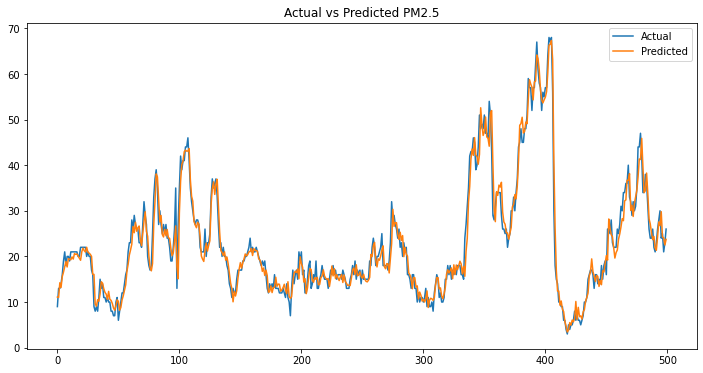

In [49]:
plt.figure(figsize=(12,6))

plt.plot(
    y_test.values[:500],
    label='Actual'
)

plt.plot(
    predictions[:500],
    label='Predicted'
)

plt.legend()
plt.title('Actual vs Predicted PM2.5')
plt.show()

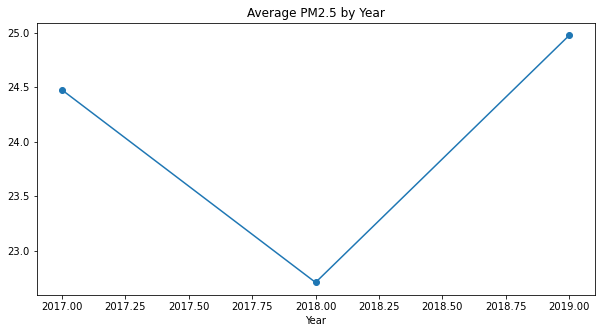

In [50]:
yearly_pm25 = (
    pivot_df.groupby('Year')['PM2.5']
    .mean()
)

yearly_pm25.plot(
    figsize=(10,5),
    marker='o'
)

plt.title('Average PM2.5 by Year')
plt.show()

### 
2017 → relatively high PM2.5;
2018 → lowest PM2.5;
2019 → highest PM2.5

In [51]:
station_count = (
    pivot_df.groupby('Station name(district)')
    ['PM2.5']
    .count()
)

print(station_count.sort_values(ascending=False))

Station name(district)
Jung-gu            25546
Nowon-gu           25452
Geumcheon-gu       25416
Gangbuk-gu         25375
Dongjak-gu         25197
Yangcheon-gu       25147
Jongno-gu          24899
Yongsan-gu         24638
Gangseo-gu         24450
Songpa-gu          24337
Dongdaemun-gu      24231
Gangdong-gu        24126
Gangnam-gu         24085
Guro-gu            24049
Seocho-gu          24025
Eunpyeong-gu       23865
Seongbuk-gu        23831
Seongdong-gu       23816
Yeongdeungpo-gu    23747
Jungnang-gu        23743
Dobong-gu          23628
Mapo-gu            23311
Seodaemun-gu       23106
Gwanak-gu          22561
Gwangjin-gu        21870
Name: PM2.5, dtype: int64


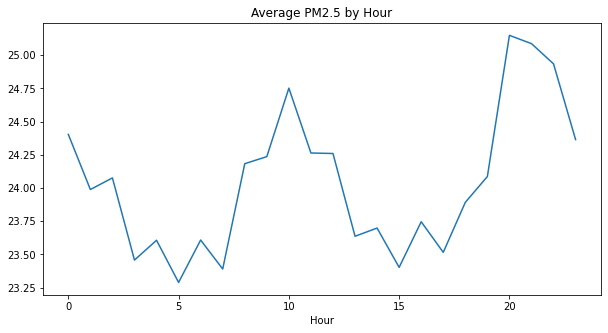

In [52]:
pivot_df.groupby('Hour')['PM2.5'].mean().plot(
    figsize=(10,5)
)

plt.title('Average PM2.5 by Hour')
plt.show()

In [1]:
!pip install xgboost

In [63]:
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

In [64]:
xgb_model = XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)



In [65]:
xgb_model.fit(X_train, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.8, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             gamma=None, grow_policy=None, importance_type=None,
             interaction_constraints=None, learning_rate=0.05, max_bin=None,
             max_cat_threshold=None, max_cat_to_onehot=None,
             max_delta_step=None, max_depth=6, max_leaves=None,
             min_child_weight=None, missing=nan, monotone_constraints=None,
             multi_strategy=None, n_estimators=300, n_jobs=None,
             num_parallel_tree=None, random_state=42, ...)

In [66]:
xgb_pred = xgb_model.predict(X_test)

In [67]:
xgb_mae = mean_absolute_error(y_test, xgb_pred)
xgb_rmse = np.sqrt(mean_squared_error(y_test, xgb_pred))
xgb_r2 = r2_score(y_test, xgb_pred)

print("XGBoost Results")
print(f"MAE  : {xgb_mae:.2f}")
print(f"RMSE : {xgb_rmse:.2f}")
print(f"R²   : {xgb_r2:.4f}")

XGBoost Results
MAE  : 3.18
RMSE : 4.51
R²   : 0.9448


In [68]:
comparison = pd.DataFrame({
    "Model": ["Random Forest", "XGBoost"],
    "RMSE": [rmse, xgb_rmse],
    "R2": [r2, xgb_r2]
})

comparison

,Model,RMSE,R2
0,Random Forest,4.565590,0.943487
1,XGBoost,4.512651,0.944790


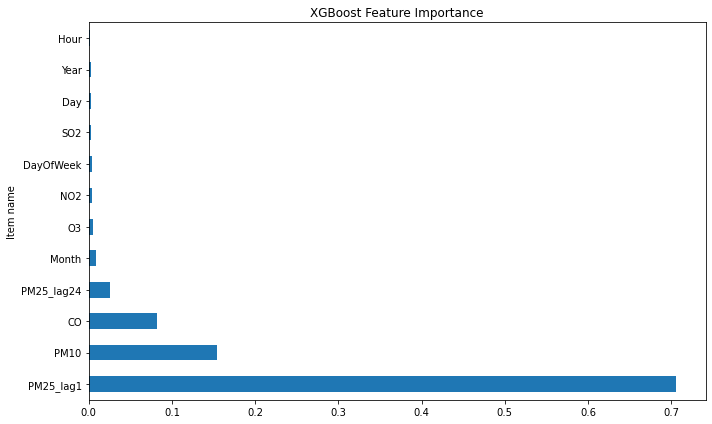

In [69]:
import matplotlib.pyplot as plt

importance = pd.Series(
    xgb_model.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False)

plt.figure(figsize=(10,6))
importance.head(15).plot(kind='barh')
plt.title("XGBoost Feature Importance")
plt.tight_layout()
plt.show()

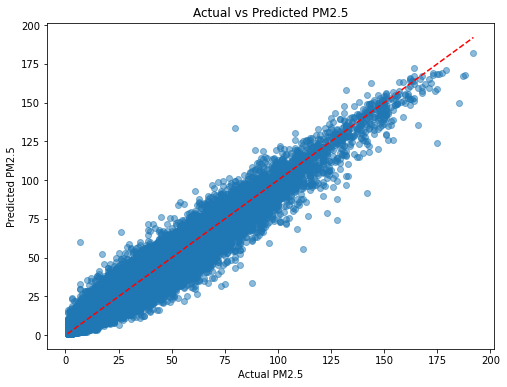

In [70]:
plt.figure(figsize=(8,6))
plt.scatter(y_test, xgb_pred, alpha=0.5)

plt.xlabel("Actual PM2.5")
plt.ylabel("Predicted PM2.5")
plt.title("Actual vs Predicted PM2.5")

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    'r--'
)

plt.show()